# 1. Importation des bibliothèques

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import mlflow
import mlflow.sklearn
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import streamlit as st
import numpy as np

## 2. Chargement du dataset

In [2]:
# Charger le dataset
df = pd.read_csv("credit_scoring_dataset_v2.csv")

## 3. Exploration des données

In [3]:
# Aperçu
print(df.head())
print(df.info())
print(df.describe())

   Age  Revenu  Montant_Credit  Duree_Mois  Score_Credit  Nb_Credits_Prec  \
0   56   40.81           48.24          32           700                2   
1   69   60.67           45.63          69           455                2   
2   46   56.67           36.35           7           384                4   
3   32  142.85            9.35          31           309                2   
4   60  145.59           17.34          74           437                5   

   Ratio_Dette_Revenu Statut_Emploi Niveau_Education Type_Propriete  \
0                8.57           CDI           Master   Propriétaire   
1               84.25           CDI           Master   Propriétaire   
2               33.82           CDD          Licence   Propriétaire   
3               21.82           CDD          Licence   Propriétaire   
4               87.15           CDI           Master   Propriétaire   

  Historique_Credit   Objet_Credit  Defaut_Paiement  
0               Bon     Immobilier                0  
1 

## 4. Prétraitement des données
- Numériques : standardisation avec StandardScaler (Age, Revenu, Montant_Credit…).

- Catégoriques : encodage avec OneHotEncoder.

- Split train/test : 80/20.

In [4]:

X = df.drop("Defaut_Paiement", axis=1)
y = df["Defaut_Paiement"]

num_features = ["Age","Revenu","Montant_Credit","Duree_Mois","Score_Credit","Nb_Credits_Prec","Ratio_Dette_Revenu"]
cat_features = ["Statut_Emploi","Niveau_Education","Type_Propriete","Historique_Credit","Objet_Credit"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5. Modélisation classique (Scikit-Learn)
Tester plusieurs modèles : KNN, DecisionTree, RandomForest.

In [5]:
# Liste des modèles à tester
modeles = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Arbre de Décision", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]

# Boucle pour tester chaque modèle
for nom, clf in modeles:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n=== Résultats {nom} ===")
    print(classification_report(y_test, y_pred))



=== Résultats KNN ===
              precision    recall  f1-score   support

           0       0.53      0.48      0.50       343
           1       0.64      0.67      0.65       457

    accuracy                           0.59       800
   macro avg       0.58      0.58      0.58       800
weighted avg       0.59      0.59      0.59       800


=== Résultats Arbre de Décision ===
              precision    recall  f1-score   support

           0       0.50      0.50      0.50       343
           1       0.62      0.63      0.63       457

    accuracy                           0.57       800
   macro avg       0.56      0.56      0.56       800
weighted avg       0.57      0.57      0.57       800


=== Résultats Random Forest ===
              precision    recall  f1-score   support

           0       0.63      0.43      0.51       343
           1       0.65      0.81      0.72       457

    accuracy                           0.65       800
   macro avg       0.64      0.62  

## 📊 Courbes d’évolution des métriques (Accuracy, F1, etc.)

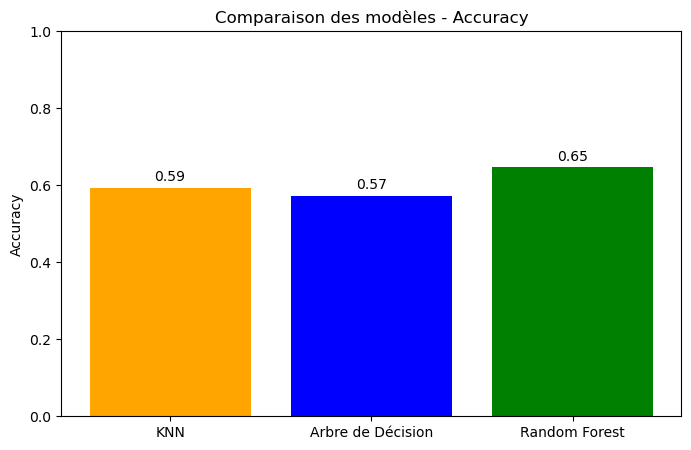

Résultats Accuracy : {'KNN': 0.5925, 'Arbre de Décision': 0.5725, 'Random Forest': 0.64625}


In [17]:
# Dictionnaire pour stocker les résultats
results = {}

# Boucle pour calculer l'accuracy de chaque modèle
for nom, clf in modeles:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[nom] = acc

# Graphique comparatif
plt.figure(figsize=(8,5))
bars = plt.bar(results.keys(), results.values(), color=['orange','blue','green'])
plt.title("Comparaison des modèles - Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1)  # pour bien voir les scores entre 0 et 1

# Ajouter les valeurs d'accuracy au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha='center', va='bottom', fontsize=10)

plt.show()

print("Résultats Accuracy :", results)


## 📈 Courbes ROC et AUC

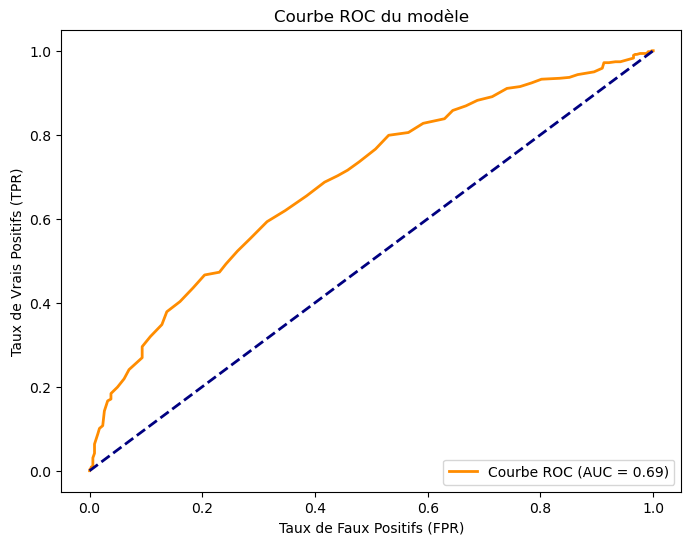

In [7]:
# Probabilités de prédiction (classe 1 = défaut)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calcul des points ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Tracé de la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label="Courbe ROC (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("Taux de Faux Positifs (FPR)")
plt.ylabel("Taux de Vrais Positifs (TPR)")
plt.title("Courbe ROC du modèle")
plt.legend(loc="lower right")
plt.show()

## Distribution de la variable cible

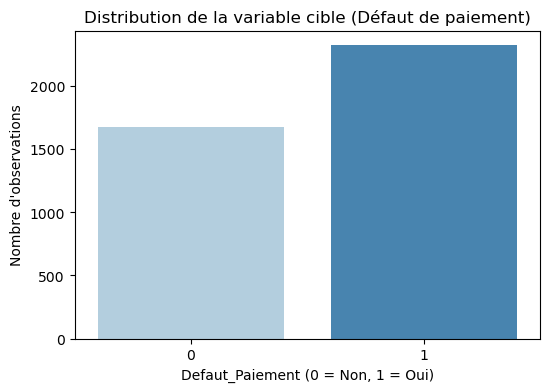

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Defaut_Paiement", data=df, hue="Defaut_Paiement", palette="Blues", legend=False)
plt.title("Distribution de la variable cible (Défaut de paiement)")
plt.xlabel("Defaut_Paiement (0 = Non, 1 = Oui)")
plt.ylabel("Nombre d'observations")
plt.show()

## Les matrices de confusion des 3 modèles

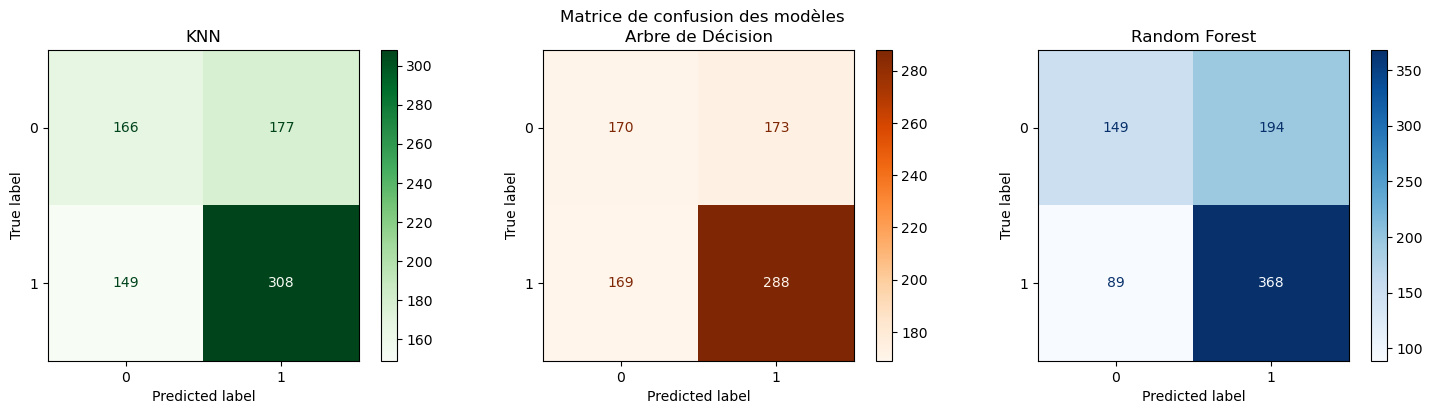

In [14]:
# Liste des modèles à tester avec palettes associées
modeles = [
    ("KNN", KNeighborsClassifier(n_neighbors=5), "Greens"),
    ("Arbre de Décision", DecisionTreeClassifier(random_state=42), "Oranges"),
    ("Random Forest", RandomForestClassifier(random_state=42), "Blues")
]

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Boucle pour afficher chaque matrice de confusion dans un subplot
for ax, (nom, clf, cmap) in zip(axes, modeles):
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    model.fit(X_train, y_train)
    
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=cmap, ax=ax)
    ax.set_title(f"{nom}")
    
    # Ajouter un fond coloré sur la diagonale
    cm = disp.confusion_matrix
    for i in range(len(cm)):
        # Couleur attractive différente selon le modèle
        if nom == "KNN":
            color = "lightgreen"
        elif nom == "Arbre de Décision":
            color = "gold"
        else:  # Random Forest
            color = "lightblue"
        
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, 
                                   fill=True, color=color, alpha=0.3, zorder=-1))

plt.suptitle("Matrice de confusion des modèles")
plt.tight_layout()
plt.show()


## 6. Suivi avec MLflow

In [16]:
# Liste des modèles
modeles = [
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Arbre de Décision", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]

best_model = None
best_score = 0
best_name = ""
best_f1 = 0
best_precision = 0
best_recall = 0

# Boucle pour tester et comparer les modèles
for nom, clf in modeles:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f"{nom} - Accuracy : {acc:.4f} | F1-score : {f1:.4f} | Precision : {precision:.4f} | Recall : {recall:.4f}")
    
    # Vérifier si c'est le meilleur modèle (selon accuracy ici)
    if acc > best_score:
        best_score = acc
        best_f1 = f1
        best_precision = precision
        best_recall = recall
        best_model = model
        best_name = nom

# Créer ou utiliser l'expérience MLflow
mlflow.set_experiment("CreditScoring")

with mlflow.start_run(run_name=f"BestModel-{best_name}"):
    # Réentraîner pour être sûr
    best_model.fit(X_train, y_train)
    
    # Log du modèle avec format sûr et dépendances explicites
    mlflow.sklearn.log_model(
        best_model,
        name="best_model",
        serialization_format="skops",
        pip_requirements=["scikit-learn==1.7.2", "skops==0.13.0"]
    )
    
    # Log des métriques
    mlflow.log_metric("accuracy", best_score)
    mlflow.log_metric("f1_score", best_f1)
    mlflow.log_metric("precision", best_precision)
    mlflow.log_metric("recall", best_recall)
    
    # Log des hyperparamètres du classifieur
    mlflow.log_params(best_model.named_steps["classifier"].get_params())

print(f"\n✅ Le meilleur modèle est {best_name} avec Accuracy = {best_score:.4f}, "
      f"F1-score = {best_f1:.4f}, Precision = {best_precision:.4f}, Recall = {best_recall:.4f}")

KNN - Accuracy : 0.5925 | F1-score : 0.6539 | Precision : 0.6351 | Recall : 0.6740
Arbre de Décision - Accuracy : 0.5725 | F1-score : 0.6275 | Precision : 0.6247 | Recall : 0.6302
Random Forest - Accuracy : 0.6462 | F1-score : 0.7223 | Precision : 0.6548 | Recall : 0.8053

✅ Le meilleur modèle est Random Forest avec Accuracy = 0.6462, F1-score = 0.7223, Precision = 0.6548, Recall = 0.8053
